In [2]:
# MIMIC-IV 30-Day Readmission Prediction
## Notebook 1: Data Extraction and Target Variable Construction

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


In [4]:
# Paths
DATA_DIR = Path('../data')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Verify data files exist
files = ['admissions.csv.gz', 'patients.csv.gz', 
         'diagnoses_icd.csv.gz', 'prescriptions.csv.gz']

for f in files:
    path = DATA_DIR / f
    size_mb = path.stat().st_size / 1024 / 1024
    print(f"{f}: {size_mb:.1f} MB ✓" if path.exists() else f"{f}: NOT FOUND ✗")

admissions.csv.gz: 19.0 MB ✓
patients.csv.gz: 2.7 MB ✓
diagnoses_icd.csv.gz: 32.0 MB ✓
prescriptions.csv.gz: 578.2 MB ✓


In [5]:
print("Loading admissions...")
admissions = pd.read_csv(DATA_DIR / 'admissions.csv.gz')
print(f"Shape: {admissions.shape}")
admissions.head()

Loading admissions...
Shape: (546028, 16)


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [6]:
print("=== ADMISSIONS TABLE ===")
print(f"\nShape: {admissions.shape}")
print(f"\nColumn types:\n{admissions.dtypes}")
print(f"\nMissing values:\n{admissions.isnull().sum()}")
print(f"\nBasic stats:")
admissions.describe()

=== ADMISSIONS TABLE ===

Shape: (546028, 16)

Column types:
subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
admission_type          object
admit_provider_id       object
admission_location      object
discharge_location      object
insurance               object
language                object
marital_status          object
race                    object
edregtime               object
edouttime               object
hospital_expire_flag     int64
dtype: object

Missing values:
subject_id                   0
hadm_id                      0
admittime                    0
dischtime                    0
deathtime               534238
admission_type               0
admit_provider_id            4
admission_location           1
discharge_location      149818
insurance                 9355
language                   775
marital_status           13619
race                         0
edregtime

,subject_id,hadm_id,hospital_expire_flag
count,546028.00,546028.00,546028.00
mean,15011181.26,25001002.58,0.02
std,2877694.30,2888710.20,0.15
min,10000032.00,20000019.00,0.00
25%,12523805.00,22496622.25,0.00
50%,15019607.50,25003849.00,0.00
75%,17504026.00,27502819.75,0.00
max,19999987.00,29999935.00,1.00


In [7]:
print("Loading patients...")
patients = pd.read_csv(DATA_DIR / 'patients.csv.gz')
print(f"Shape: {patients.shape}")
print(f"\nColumn types:\n{patients.dtypes}")
print(f"\nMissing values:\n{patients.isnull().sum()}")
patients.head()

Loading patients...
Shape: (364627, 6)

Column types:
subject_id            int64
gender               object
anchor_age            int64
anchor_year           int64
anchor_year_group    object
dod                  object
dtype: object

Missing values:
subject_id                0
gender                    0
anchor_age                0
anchor_year               0
anchor_year_group         0
dod                  326326
dtype: int64


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [8]:
print("Loading diagnoses...")
diagnoses = pd.read_csv(DATA_DIR / 'diagnoses_icd.csv.gz')
print(f"Shape: {diagnoses.shape}")
print(f"\nColumn types:\n{diagnoses.dtypes}")
print(f"\nMissing values:\n{diagnoses.isnull().sum()}")
diagnoses.head()

Loading diagnoses...
Shape: (6364488, 5)

Column types:
subject_id      int64
hadm_id         int64
seq_num         int64
icd_code       object
icd_version     int64
dtype: object

Missing values:
subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [9]:
print("Loading prescriptions...")
prescriptions = pd.read_csv(DATA_DIR / 'prescriptions.csv.gz')
print(f"Shape: {prescriptions.shape}")
print(f"\nColumn types:\n{prescriptions.dtypes}")
print(f"\nMissing values:\n{prescriptions.isnull().sum()}")
prescriptions.head()

Loading prescriptions...
Shape: (20292611, 21)

Column types:
subject_id             int64
hadm_id                int64
pharmacy_id            int64
poe_id                object
poe_seq              float64
order_provider_id     object
starttime             object
stoptime              object
drug_type             object
drug                  object
formulary_drug_cd     object
gsn                   object
ndc                  float64
prod_strength         object
form_rx               object
dose_val_rx           object
dose_unit_rx          object
form_val_disp         object
form_unit_disp        object
doses_per_24_hrs     float64
route                 object
dtype: object

Missing values:
subject_id                  0
hadm_id                     0
pharmacy_id                 0
poe_id                 184441
poe_seq                184441
order_provider_id       66367
starttime               21890
stoptime                31436
drug_type                   0
drug                        

,subject_id,hadm_id,pharmacy_id,poe_id,poe_seq,order_provider_id,starttime,stoptime,drug_type,drug,formulary_drug_cd,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
0,10000032,22595853,12775705,10000032-55,55.00,P85UQ1,2180-05-08 08:00:00,2180-05-07 22:00:00,MAIN,Furosemide,FURO40,008209,51079007320.00,40mg Tablet,NaN,40,mg,1,TAB,1.00,PO/NG
1,10000032,22595853,18415984,10000032-42,42.00,P23SJA,2180-05-07 02:00:00,2180-05-07 22:00:00,MAIN,Ipratropium Bromide Neb,IPRA2H,021700,487980125.00,2.5mL Vial,NaN,1,NEB,1,VIAL,4.00,IH
2,10000032,22595853,23637373,10000032-35,35.00,P23SJA,2180-05-07 01:00:00,2180-05-07 09:00:00,MAIN,Furosemide,FURO20,008208,51079007220.00,20mg Tablet,NaN,20,mg,1,TAB,1.00,PO/NG
3,10000032,22595853,26862314,10000032-41,41.00,P23SJA,2180-05-07 01:00:00,2180-05-07 01:00:00,MAIN,Potassium Chloride,MICROK10,001275,245004101.00,10mEq ER Tablet,NaN,40,mEq,4,TAB,1.00,PO
4,10000032,22595853,30740602,10000032-27,27.00,P23SJA,2180-05-07 00:00:00,2180-05-07 22:00:00,MAIN,Sodium Chloride 0.9% Flush,NACLFLUSH,NaN,0.00,10 mL Syringe,NaN,3,mL,0.3,SYR,3.00,IV


In [10]:
# Convert datetime columns from strings to datetime objects
datetime_cols = ['admittime', 'dischtime', 'deathtime', 
                 'edregtime', 'edouttime']

for col in datetime_cols:
    admissions[col] = pd.to_datetime(admissions[col])

print("Datetime conversion complete")
print(f"\nSample admit times:\n{admissions['admittime'].head()}")
print(f"\nDate range: {admissions['admittime'].min()} to {admissions['admittime'].max()}")

Datetime conversion complete

Sample admit times:
0   2180-05-06 22:23:00
1   2180-06-26 18:27:00
2   2180-08-05 23:44:00
3   2180-07-23 12:35:00
4   2160-03-03 23:16:00
Name: admittime, dtype: datetime64[ns]

Date range: 2105-10-04 17:26:00 to 2214-12-15 19:11:00


=== ADMISSIONS PER PATIENT ===
Total unique patients: 223,452
Total admissions: 546,028

Distribution of admissions per patient:
count   223452.00
mean         2.44
std          3.57
min          1.00
25%          1.00
50%          1.00
75%          3.00
max        238.00
Name: hadm_id, dtype: float64


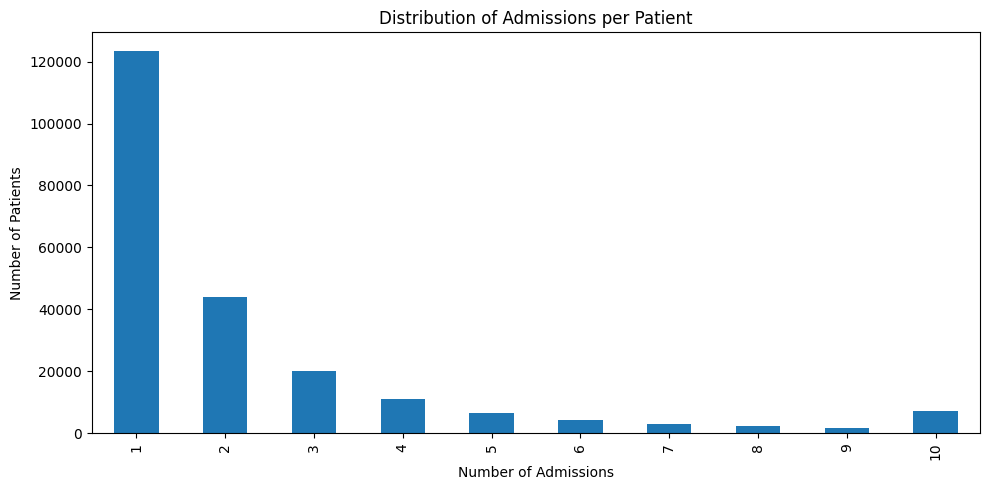

Figure saved


In [11]:
admissions_per_patient = admissions.groupby('subject_id')['hadm_id'].count()

print("=== ADMISSIONS PER PATIENT ===")
print(f"Total unique patients: {admissions['subject_id'].nunique():,}")
print(f"Total admissions: {len(admissions):,}")
print(f"\nDistribution of admissions per patient:")
print(admissions_per_patient.describe())

plt.figure(figsize=(10, 5))
admissions_per_patient.clip(upper=10).value_counts().sort_index().plot(kind='bar')
plt.xlabel('Number of Admissions')
plt.ylabel('Number of Patients')
plt.title('Distribution of Admissions per Patient')
plt.tight_layout()
plt.savefig('../figures/admissions_per_patient.png', dpi=150)
plt.show()
print("Figure saved")

In [12]:
print("=== BUILDING BASE COHORT ===")
print(f"Starting admissions: {len(admissions):,}")

# Step 1 - Remove admissions where patient died in hospital
# These patients cannot be readmitted so we exclude them
died_in_hospital = admissions['hospital_expire_flag'] == 1
print(f"Removing {died_in_hospital.sum():,} admissions where patient died in hospital")
cohort = admissions[~died_in_hospital].copy()
print(f"Remaining admissions: {len(cohort):,}")

# Step 2 - Remove admissions with missing discharge time
missing_disch = cohort['dischtime'].isnull()
print(f"Removing {missing_disch.sum():,} admissions with missing discharge time")
cohort = cohort[~missing_disch].copy()
print(f"Remaining admissions: {len(cohort):,}")

# Step 3 - Sort by patient and admission time
cohort = cohort.sort_values(['subject_id', 'admittime']).reset_index(drop=True)
print(f"\nFinal base cohort: {len(cohort):,} admissions")
print(f"Unique patients: {cohort['subject_id'].nunique():,}")

=== BUILDING BASE COHORT ===
Starting admissions: 546,028
Removing 11,801 admissions where patient died in hospital
Remaining admissions: 534,227
Removing 0 admissions with missing discharge time
Remaining admissions: 534,227

Final base cohort: 534,227 admissions
Unique patients: 218,196


In [13]:
print("=== CONSTRUCTING 30-DAY READMISSION TARGET ===")

# For each admission, find the next admission for the same patient
# by shifting the admittime column within each patient group
cohort['next_admittime'] = cohort.groupby('subject_id')['admittime'].shift(-1)

# Calculate days between discharge and next admission
cohort['days_to_readmission'] = (
    cohort['next_admittime'] - cohort['dischtime']
).dt.total_seconds() / (24 * 3600)

# Create binary target variable
# 1 if next admission within 30 days, 0 otherwise
cohort['readmitted_30'] = (
    (cohort['days_to_readmission'] >= 0) & 
    (cohort['days_to_readmission'] <= 30)
).astype(int)

print(f"\nTarget variable distribution:")
print(cohort['readmitted_30'].value_counts())
print(f"\nReadmission rate: {cohort['readmitted_30'].mean():.1%}")

=== CONSTRUCTING 30-DAY READMISSION TARGET ===

Target variable distribution:
readmitted_30
0    427854
1    106373
Name: count, dtype: int64

Readmission rate: 19.9%


In [14]:
# Exclude cases where discharge and next admission are less than 
# 24 hours apart - these are likely transfers not true readmissions
transfers = (cohort['days_to_readmission'] >= 0) & (cohort['days_to_readmission'] < 1)
print(f"Identified {transfers.sum():,} potential transfers (readmitted within 24 hours)")

# Mark these as not readmissions
cohort.loc[transfers, 'readmitted_30'] = 0

print(f"\nFinal target variable distribution after excluding transfers:")
print(cohort['readmitted_30'].value_counts())
print(f"\nFinal readmission rate: {cohort['readmitted_30'].mean():.1%}")

Identified 13,609 potential transfers (readmitted within 24 hours)

Final target variable distribution after excluding transfers:
readmitted_30
0    441463
1     92764
Name: count, dtype: int64

Final readmission rate: 17.4%


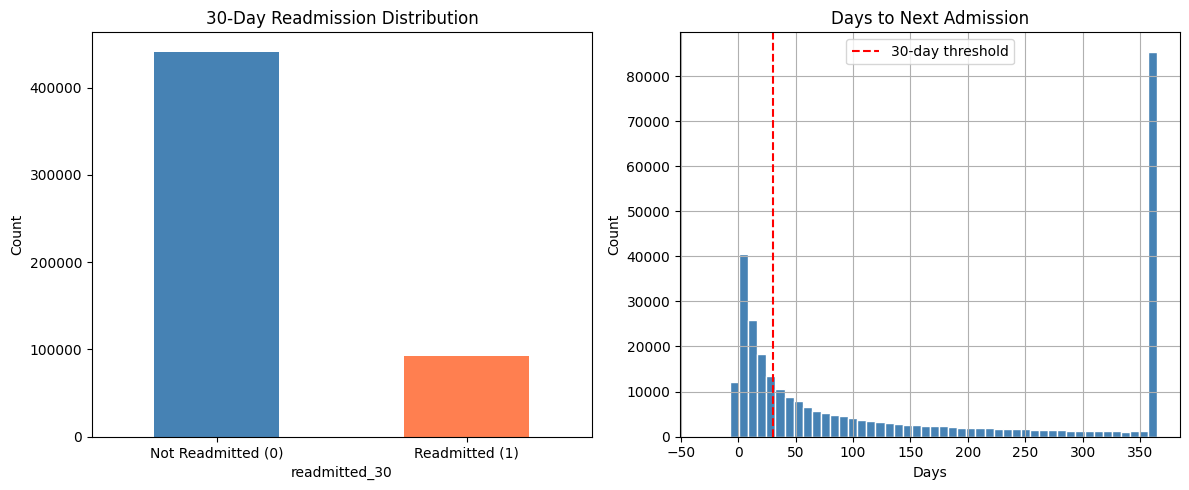

Figure saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 - Target variable distribution
cohort['readmitted_30'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'coral']
)
axes[0].set_xticklabels(['Not Readmitted (0)', 'Readmitted (1)'], rotation=0)
axes[0].set_title('30-Day Readmission Distribution')
axes[0].set_ylabel('Count')

# Plot 2 - Distribution of days to readmission
cohort['days_to_readmission'].dropna().clip(upper=365).hist(
    bins=50, ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].axvline(x=30, color='red', linestyle='--', label='30-day threshold')
axes[1].set_title('Days to Next Admission')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/readmission_distribution.png', dpi=150)
plt.show()
print("Figure saved")

In [16]:
# Save the base cohort for use in the next notebook
output_path = Path('../data/cohort_base.csv')
cohort.to_csv(output_path, index=False)
print(f"Base cohort saved to {output_path}")
print(f"Shape: {cohort.shape}")
print(f"\nColumns: {list(cohort.columns)}")

Base cohort saved to ../data/cohort_base.csv
Shape: (534227, 19)

Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'next_admittime', 'days_to_readmission', 'readmitted_30']


In [17]:
print("=== SANITY CHECKS ===")

# Check no negative days to readmission in positive cases
negative_days = cohort[cohort['readmitted_30'] == 1]['days_to_readmission'] < 0
print(f"Readmissions with negative days (should be 0): {negative_days.sum()}")

# Check readmission days range for positive cases
pos_cases = cohort[cohort['readmitted_30'] == 1]['days_to_readmission']
print(f"\nDays to readmission for positive cases:")
print(f"Min: {pos_cases.min():.1f} days")
print(f"Max: {pos_cases.max():.1f} days")
print(f"Mean: {pos_cases.mean():.1f} days")
print(f"Median: {pos_cases.median():.1f} days")

# Check distribution by admission type
print(f"\nReadmission rate by admission type:")
print(cohort.groupby('admission_type')['readmitted_30'].agg(['mean', 'count'])
      .round(3)
      .sort_values('mean', ascending=False))

=== SANITY CHECKS ===
Readmissions with negative days (should be 0): 0

Days to readmission for positive cases:
Min: 1.0 days
Max: 30.0 days
Mean: 12.1 days
Median: 10.6 days

Readmission rate by admission type:
                             mean   count
admission_type                           
DIRECT EMER.                 0.31   21489
ELECTIVE                     0.29   13036
OBSERVATION ADMIT            0.20   82598
EW EMER.                     0.19  170809
DIRECT OBSERVATION           0.18   24521
AMBULATORY OBSERVATION       0.15    7194
SURGICAL SAME DAY ADMISSION  0.14   42750
URGENT                       0.14   52484
EU OBSERVATION               0.12  119346


In [18]:
print("Readmission rate by discharge location:")
discharge_stats = (cohort.groupby('discharge_location')['readmitted_30']
                   .agg(['mean', 'count'])
                   .round(3)
                   .sort_values('mean', ascending=False))
print(discharge_stats)

# This is clinically interesting - certain discharge locations
# should have higher readmission rates

Readmission rate by discharge location:
                              mean   count
discharge_location                        
AGAINST ADVICE                0.28    3393
CHRONIC/LONG TERM ACUTE CARE  0.25    8121
HOME HEALTH CARE              0.24   99296
SKILLED NURSING FACILITY      0.20   52642
OTHER FACILITY                0.19    1591
ASSISTED LIVING               0.18     622
HOME                          0.17  194116
REHAB                         0.17   13842
ACUTE HOSPITAL                0.16    2332
HEALTHCARE FACILITY           0.14      50
PSYCH FACILITY                0.05    2964
HOSPICE                       0.04    5375
DIED                          0.00     227


In [19]:
print("=== NOTEBOOK 1 SUMMARY ===")
print(f"Total admissions in cohort: {len(cohort):,}")
print(f"Unique patients: {cohort['subject_id'].nunique():,}")
print(f"Readmission rate: {cohort['readmitted_30'].mean():.1%}")
print(f"Positive cases (readmitted): {cohort['readmitted_30'].sum():,}")
print(f"Negative cases (not readmitted): {(cohort['readmitted_30']==0).sum():,}")
print(f"Class imbalance ratio: 1:{(cohort['readmitted_30']==0).sum() // cohort['readmitted_30'].sum()}")
print(f"\nDate range of admissions:")
print(f"Earliest: {cohort['admittime'].min()}")
print(f"Latest: {cohort['admittime'].max()}")

# Save
cohort.to_csv('../data/cohort_base.csv', index=False)
print(f"\nBase cohort saved to data/cohort_base.csv")

=== NOTEBOOK 1 SUMMARY ===
Total admissions in cohort: 534,227
Unique patients: 218,196
Readmission rate: 17.4%
Positive cases (readmitted): 92,764
Negative cases (not readmitted): 441,463
Class imbalance ratio: 1:4

Date range of admissions:
Earliest: 2105-10-04 17:26:00
Latest: 2214-12-15 19:11:00

Base cohort saved to data/cohort_base.csv


## Notebook 1 Complete

### Key findings:
- **534,227 admissions** in base cohort after excluding in-hospital deaths
- **17.4% readmission rate** (92,764 positive cases)
- Clinically sensible patterns confirmed:
  - Direct emergency admissions have highest readmission rate (31%)
  - Patients discharged against medical advice have highest readmission rate by discharge location (28%)
  - Hospice and psych facility discharges have lowest readmission rates
- No data quality issues found — zero negative readmission days, no missing discharge times

### Next steps (Notebook 2):
- Engineer features from all four tables
- Compute Elixhauser comorbidity index from diagnoses
- Aggregate prescription features
- Build final feature matrix for modeling